## Cell 1 — Install required packages

In [1]:

# Run once. If using a local conda/venv env, run this in a terminal instead of the notebook.
!pip install -q ollama opencv-python pillow lxml pandas numpy matplotlib tqdm


## Cell 2 — Connect to Ollama and verify Qwen3-VL is running

In [2]:

import ollama

OLLAMA_MODEL = "qwen2.5vl:7b"  # change tag to match `ollama list` output, e.g. qwen3-vl:8b

client = ollama.Client(host="http://localhost:11434")

# Verify the Ollama server is reachable and the model is pulled
try:
    models = client.list()
    names = [m.get("model", m.get("name", "")) for m in models.get("models", [])]
    print("Models available on Ollama server:")
    for n in names:
        print(" -", n)

    if not any(OLLAMA_MODEL.split(":")[0] in n for n in names):
        print(f"\n⚠️  '{OLLAMA_MODEL}' not found. Pull it first with:")
        print(f"    ollama pull {OLLAMA_MODEL}")
    else:
        print(f"\n✅ '{OLLAMA_MODEL}' is available.")
except Exception as e:
    print("❌ Could not connect to Ollama. Is it running? Try `ollama serve` in a terminal.")
    print("Error:", e)


Models available on Ollama server:
 - moondream:latest
 - qwen2.5vl:7b
 - gemma3:4b
 - llava:7b
 - qwen3-vl:latest

✅ 'qwen2.5vl:7b' is available.


## Cell 3 — Load one test image

Found 50 images.
Testing on: 00094.jpg | size: (1280, 720)


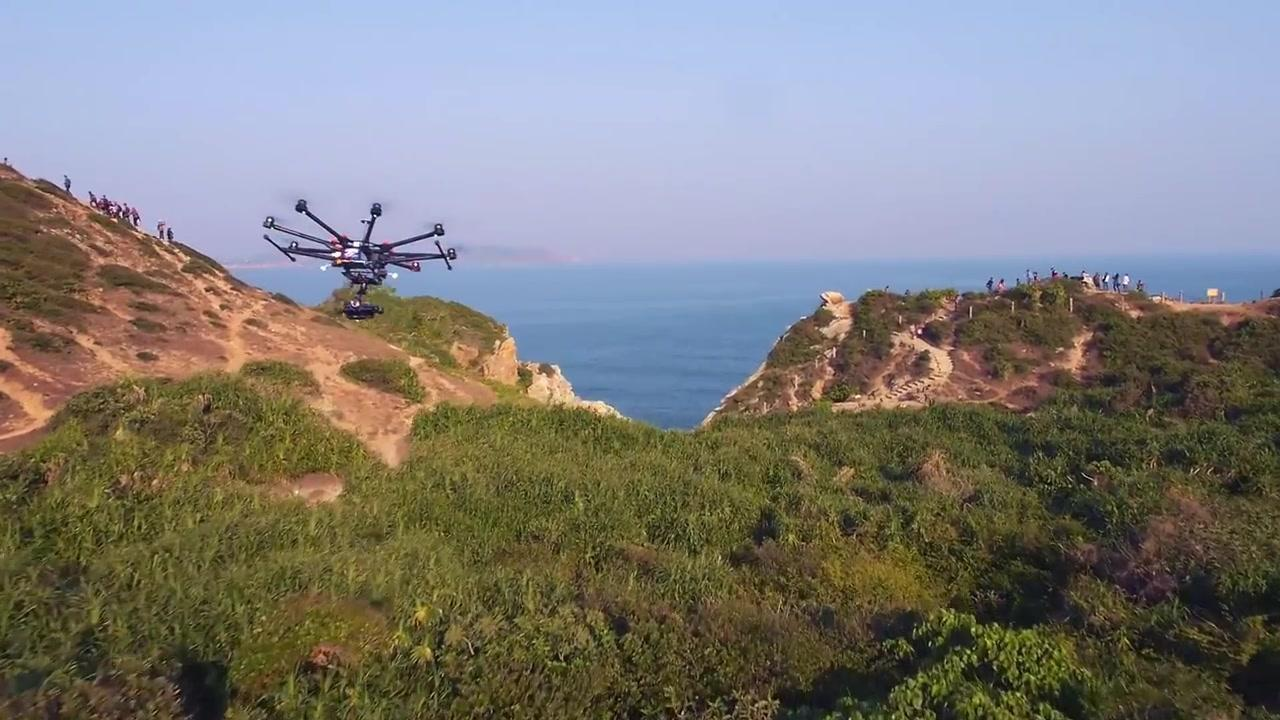

In [3]:

import os
from PIL import Image

IMAGES_DIR = r"C:\\Users\\HP\\OneDrive\\Documents\\Desktop\\vlm\\data\\detection_drone\\img"   # your images folder
ANNOTS_DIR = r"C:\\Users\\HP\\OneDrive\\Documents\\Desktop\\vlm\\data\\detection_drone\\xml"   # your ground-truth Pascal VOC XMLs
PRED_DIR   = r"C:\\Users\\HP\\OneDrive\\Documents\\Desktop\\vlm\\data\\detection_drone\\qwen25vl_predictions_xml"
os.makedirs(PRED_DIR, exist_ok=True)

image_files = sorted([f for f in os.listdir(IMAGES_DIR)
                       if f.lower().endswith((".jpg", ".jpeg", ".png"))])
print(f"Found {len(image_files)} images.")

# Sanity check: flag any image that has no matching ground-truth XML
missing_gt = [f for f in image_files
              if not os.path.exists(os.path.join(ANNOTS_DIR, os.path.splitext(f)[0] + ".xml"))]
if missing_gt:
    print(f"WARNING: {len(missing_gt)} image(s) have NO ground-truth XML (will be treated as 'no object' GT):")
    for m in missing_gt:
        print("   -", m)

test_image_name = image_files[0]
test_image_path = os.path.join(IMAGES_DIR, test_image_name)

img = Image.open(test_image_path).convert("RGB")
print("Testing on:", test_image_name, "| size:", img.size)
img


## Cell 4 — Prompt Qwen2.5-VL (Zero-shot / Few-shot / Chain-of-Thought)


In [4]:

import base64
from io import BytesIO

def image_to_b64(pil_img):
    buf = BytesIO()
    pil_img.save(buf, format="JPEG")
    return base64.b64encode(buf.getvalue()).decode("utf-8")

# ---------------------------------------------------------------------------
# Three prompting strategies are supported: "zero_shot", "few_shot", and
# "chain_of_thought". Each has its OWN system prompt and user prompt so the
# model is given a different amount of guidance/context in each condition.
# ---------------------------------------------------------------------------

RESPONSE_FORMAT_INSTRUCTIONS = (
    "Respond in EXACTLY this format and nothing else:\n"
    "YES\nxmin,ymin,xmax,ymax\n"
    "or\n"
    "NO"
)

def build_system_prompt(prompt_type, img_w, img_h):
    base_persona = (
        f"You are a precise computer-vision object detector specialised in finding small, "
        f"distant aerial drones in images of size {img_w}x{img_h} pixels "
        f"(width x height, origin top-left)."
    )
    if prompt_type == "zero_shot":
        return (
            base_persona + " You are given a single image and must decide, with no prior "
            "examples, whether a drone is present and where."
        )
    elif prompt_type == "few_shot":
        return (
            base_persona + " You will first be shown a couple of worked examples that "
            "demonstrate the exact input/output format, followed by the real image to "
            "evaluate. Follow the demonstrated format precisely."
        )
    elif prompt_type == "chain_of_thought":
        return (
            base_persona + " Before answering, reason step by step about visual evidence "
            "(shape, colour contrast against the sky/background, motion blur, size relative "
            "to the frame) to decide whether the object is a drone. Keep your reasoning brief, "
            "then give your final answer on its own line in the required format."
        )
    else:
        raise ValueError(f"Unknown prompt_type: {prompt_type}")

def build_user_prompt(prompt_type, img_w, img_h):
    task = (
        f"Step 1: Is there a drone visible in this {img_w}x{img_h} image? Answer strictly YES or NO.\n"
        f"Step 2: If YES, give the tightest bounding box around the drone in pixel coordinates "
        f"as xmin,ymin,xmax,ymax (integers, comma-separated, no spaces, no extra text).\n\n"
    )

    if prompt_type == "zero_shot":
        return task + RESPONSE_FORMAT_INSTRUCTIONS

    elif prompt_type == "few_shot":
        examples = (
            "Here are two worked examples:\n\n"
            "Example 1 (a drone is present, small and near the top-right of the frame):\n"
            "YES\n812,140,861,178\n\n"
            "Example 2 (no drone is present, only sky and clouds):\n"
            "NO\n\n"
            "Now evaluate the new image below using the same format.\n\n"
        )
        return examples + task + RESPONSE_FORMAT_INSTRUCTIONS

    elif prompt_type == "chain_of_thought":
        return (
            task
            + "First, briefly reason step by step (2-3 short sentences) about what you observe "
            "in the image and why it does or does not look like a drone. Then, on a new line, "
            "give your final answer.\n\n"
            + RESPONSE_FORMAT_INSTRUCTIONS
            + "\n\n(Your final YES/NO + coordinates line must be the LAST line of your response.)"
        )
    else:
        raise ValueError(f"Unknown prompt_type: {prompt_type}")

def query_qwen_vl(pil_img, prompt_type="zero_shot", model=OLLAMA_MODEL):
    w, h = pil_img.size
    system_prompt = build_system_prompt(prompt_type, w, h)
    user_prompt = build_user_prompt(prompt_type, w, h)

    response = client.chat(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt, "images": [image_to_b64(pil_img)]},
        ],
        options={"temperature": 0.0}
    )
    return response["message"]["content"].strip()

# Quick sanity check on the test image loaded in Cell 3, for each prompt type
for pt in ["zero_shot", "few_shot", "chain_of_thought"]:
    print(f"--- {pt} ---")
    print(query_qwen_vl(img, prompt_type=pt))
    print()


Raw model response:
YES\n263,198,457,308


## Cell 5 — Parse the response

In [5]:

import re

def parse_response(raw_text, img_w, img_h):
    # Returns (has_drone: bool, box: (xmin,ymin,xmax,ymax) or None)
    text = raw_text.strip()

    if text.upper().startswith("NO"):
        return False, None

    if "YES" not in text.upper():
        # Model didn't follow format; try to salvage any 4 numbers anyway
        nums = re.findall(r"-?\d+\.?\d*", text)
        if len(nums) >= 4:
            box = tuple(float(n) for n in nums[:4])
            return True, clamp_box(box, img_w, img_h)
        return False, None

    nums = re.findall(r"-?\d+\.?\d*", text)
    if len(nums) < 4:
        print("⚠️ Could not parse 4 coordinates from:", text)
        return True, None

    box = tuple(float(n) for n in nums[:4])
    return True, clamp_box(box, img_w, img_h)

def clamp_box(box, img_w, img_h):
    xmin, ymin, xmax, ymax = box
    xmin, xmax = sorted([xmin, xmax])
    ymin, ymax = sorted([ymin, ymax])
    xmin = max(0, min(xmin, img_w - 1))
    ymin = max(0, min(ymin, img_h - 1))
    xmax = max(0, min(xmax, img_w))
    ymax = max(0, min(ymax, img_h))
    return (int(xmin), int(ymin), int(xmax), int(ymax))

has_drone, pred_box = parse_response(raw_response, img.width, img.height)
print("Drone detected:", has_drone)
print("Predicted box:", pred_box)


Drone detected: True
Predicted box: (263, 198, 457, 308)


## Cell 6 — Draw the predicted bounding box

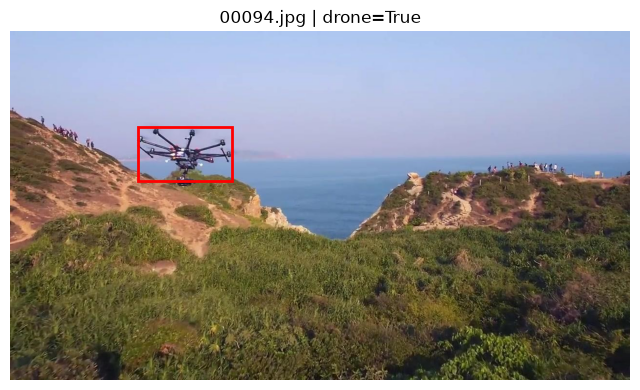

In [6]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show_prediction(pil_img, box, title="Prediction"):
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(pil_img)
    if box is not None:
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                  linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
    ax.set_title(title)
    ax.axis("off")
    plt.show()

show_prediction(img, pred_box, title=f"{test_image_name} | drone={has_drone}")


## Cell 7 — Save the prediction as a Pascal VOC XML

In [7]:

from lxml import etree

def save_voc_xml(filename, img_w, img_h, box, out_dir=PRED_DIR, label="drone"):
    ann = etree.Element("annotation")
    etree.SubElement(ann, "folder").text = "images"
    etree.SubElement(ann, "filename").text = filename

    size = etree.SubElement(ann, "size")
    etree.SubElement(size, "width").text = str(img_w)
    etree.SubElement(size, "height").text = str(img_h)
    etree.SubElement(size, "depth").text = "3"

    if box is not None:
        obj = etree.SubElement(ann, "object")
        etree.SubElement(obj, "name").text = label
        etree.SubElement(obj, "difficult").text = "0"
        bnd = etree.SubElement(obj, "bndbox")
        etree.SubElement(bnd, "xmin").text = str(box[0])
        etree.SubElement(bnd, "ymin").text = str(box[1])
        etree.SubElement(bnd, "xmax").text = str(box[2])
        etree.SubElement(bnd, "ymax").text = str(box[3])

    xml_name = os.path.splitext(filename)[0] + ".xml"
    out_path = os.path.join(out_dir, xml_name)
    tree = etree.ElementTree(ann)
    tree.write(out_path, pretty_print=True, xml_declaration=True, encoding="UTF-8")
    return out_path

saved_path = save_voc_xml(test_image_name, img.width, img.height, pred_box)
print("Saved:", saved_path)


Saved: C:\\Users\\HP\\OneDrive\\Documents\\Desktop\\vlm\\data\\detection_drone\\qwen25vl_predictions_xml\00094.xml


## Cell 8 — Run inference on all 50 images (for each prompting strategy)


In [8]:

from tqdm import tqdm
import time

PROMPT_TYPES = ["zero_shot", "few_shot", "chain_of_thought"]

# Give each prompting strategy its own predictions folder so results never mix
PRED_DIRS = {pt: os.path.join(os.path.dirname(PRED_DIR), f"qwen25vl_predictions_xml_{pt}")
             for pt in PROMPT_TYPES}
for d in PRED_DIRS.values():
    os.makedirs(d, exist_ok=True)

results_log_by_type = {pt: [] for pt in PROMPT_TYPES}

for prompt_type in PROMPT_TYPES:
    out_dir = PRED_DIRS[prompt_type]
    for fname in tqdm(image_files, desc=f"Running Qwen2.5-VL inference [{prompt_type}]"):
        fpath = os.path.join(IMAGES_DIR, fname)
        try:
            pil_img = Image.open(fpath).convert("RGB")
            raw = query_qwen_vl(pil_img, prompt_type=prompt_type)
            has_d, box = parse_response(raw, pil_img.width, pil_img.height)
            save_voc_xml(fname, pil_img.width, pil_img.height, box, out_dir=out_dir)
            results_log_by_type[prompt_type].append({
                "image": fname, "prompt_type": prompt_type, "has_drone_pred": has_d,
                "box_pred": box, "raw_response": raw
            })
        except Exception as e:
            print(f"Error on {fname} [{prompt_type}]: {e}")
            results_log_by_type[prompt_type].append({
                "image": fname, "prompt_type": prompt_type, "has_drone_pred": False,
                "box_pred": None, "raw_response": f"ERROR: {e}"
            })
        time.sleep(0.1)  # small pause to avoid overloading local Ollama server

    print(f"Done with [{prompt_type}]. Predictions saved to: {out_dir}\n")


Running Qwen3-VL inference: 100%|██████████| 50/50 [05:41<00:00,  6.84s/it]


Done. Predictions saved to: C:\\Users\\HP\\OneDrive\\Documents\\Desktop\\vlm\\data\\detection_drone\\qwen25vl_predictions_xml


## Cell 9 — Compare predicted XMLs with ground-truth XMLs (per prompting strategy)


In [9]:

def parse_voc_xml(xml_path):
    # Returns (img_w, img_h, box or None) from a Pascal VOC xml file.
    tree = etree.parse(xml_path)
    root = tree.getroot()
    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)

    obj = root.find("object")
    if obj is None:
        return w, h, None

    bnd = obj.find("bndbox")
    box = (
        int(float(bnd.find("xmin").text)),
        int(float(bnd.find("ymin").text)),
        int(float(bnd.find("xmax").text)),
        int(float(bnd.find("ymax").text)),
    )
    return w, h, box

def build_comparisons(pred_dir):
    """Compare every image's prediction (from pred_dir) against its ground-truth XML."""
    comps = []
    for fname in image_files:
        stem = os.path.splitext(fname)[0]
        gt_path = os.path.join(ANNOTS_DIR, stem + ".xml")
        pred_path = os.path.join(pred_dir, stem + ".xml")

        if not os.path.exists(pred_path):
            print(f"WARNING: Missing prediction xml for {fname} in {pred_dir}")
            continue

        if os.path.exists(gt_path):
            gt_w, gt_h, gt_box = parse_voc_xml(gt_path)
        else:
            # No GT xml on disk (e.g. 00018.jpg) -> treat as "no object" ground truth
            with Image.open(os.path.join(IMAGES_DIR, fname)) as _im:
                gt_w, gt_h = _im.size
            gt_box = None

        pr_w, pr_h, pr_box = parse_voc_xml(pred_path)

        comps.append({
            "image": fname,
            "gt_box": gt_box,
            "pred_box": pr_box,
            "gt_has_drone": gt_box is not None,
            "pred_has_drone": pr_box is not None,
        })
    return comps

# Build comparisons separately for each prompting strategy
comparisons_by_type = {pt: build_comparisons(PRED_DIRS[pt]) for pt in PROMPT_TYPES}
for pt, comps in comparisons_by_type.items():
    print(f"[{pt}] Compared {len(comps)} image pairs.")


Compared 50 image pairs.


[{'image': '00094.jpg',
  'gt_box': (263, 199, 459, 321),
  'pred_box': (263, 198, 457, 308),
  'gt_has_drone': True,
  'pred_has_drone': True},
 {'image': '00113.jpg',
  'gt_box': (614, 279, 681, 300),
  'pred_box': None,
  'gt_has_drone': True,
  'pred_has_drone': False},
 {'image': '00132.jpg',
  'gt_box': (749, 1, 943, 94),
  'pred_box': (753, 0, 948, 96),
  'gt_has_drone': True,
  'pred_has_drone': True}]

## Cell 10 — Compute IoU, Precision, Recall, F1-score, and mAP@0.5 (per prompting strategy)


In [10]:

import numpy as np

def compute_iou(boxA, boxB):
    if boxA is None or boxB is None:
        return 0.0
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = areaA + areaB - inter_area
    return inter_area / union if union > 0 else 0.0

IOU_THRESH = 0.5

def compute_metrics(comparisons):
    """Compute TP/FP/FN/TN, mean IoU, precision, recall, F1, and mAP@0.5 for one prompt type."""
    tp, fp, fn, tn = 0, 0, 0, 0
    ious = []

    for c in comparisons:
        gt_box, pred_box = c["gt_box"], c["pred_box"]
        iou = compute_iou(gt_box, pred_box) if (gt_box and pred_box) else 0.0
        c["iou"] = iou
        ious.append(iou)

        if gt_box is not None and pred_box is not None:
            if iou >= IOU_THRESH:
                tp += 1
            else:
                fp += 1
                fn += 1  # localization miss counts as both a false positive and a missed detection
        elif gt_box is not None and pred_box is None:
            fn += 1
        elif gt_box is None and pred_box is not None:
            fp += 1
        else:
            tn += 1

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    # mAP@0.5 for a single class ("drone"): rank by IoU as a proxy confidence score,
    # then compute AP via precision-recall interpolation (11-point).
    scored = sorted(comparisons, key=lambda c: c["iou"], reverse=True)
    cum_tp, cum_fp = 0, 0
    n_gt_positive = sum(1 for c in comparisons if c["gt_box"] is not None)
    precisions, recalls = [], []

    for c in scored:
        if c["gt_box"] is None:
            continue  # skip entries with no ground truth object
        if c["pred_box"] is not None and c["iou"] >= IOU_THRESH:
            cum_tp += 1
        else:
            cum_fp += 1
        p = cum_tp / (cum_tp + cum_fp)
        r = cum_tp / n_gt_positive if n_gt_positive else 0
        precisions.append(p)
        recalls.append(r)

    ap = 0.0
    if precisions:
        for t in np.linspace(0, 1, 11):
            p_at_r = [p for p, r in zip(precisions, recalls) if r >= t]
            ap += (max(p_at_r) if p_at_r else 0) / 11

    mean_iou = float(np.mean(ious)) if ious else 0.0

    return {
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "mean_iou": mean_iou, "precision": precision, "recall": recall,
        "f1": f1, "map50": ap,
    }

metrics_by_type = {}
for pt in PROMPT_TYPES:
    m = compute_metrics(comparisons_by_type[pt])
    metrics_by_type[pt] = m
    print(f"===== Evaluation Summary [{pt}] =====")
    print(f"TP={m['tp']}  FP={m['fp']}  FN={m['fn']}  TN={m['tn']}")
    print(f"Mean IoU (all pairs):  {m['mean_iou']:.4f}")
    print(f"Precision:             {m['precision']:.4f}")
    print(f"Recall:                {m['recall']:.4f}")
    print(f"F1-score:              {m['f1']:.4f}")
    print(f"mAP@0.5:               {m['map50']:.4f}")
    print()


===== Evaluation Summary =====
TP=29  FP=10  FN=21  TN=0
Mean IoU (all pairs):  0.5183
Precision:             0.7436
Recall:                0.5800
F1-score:              0.6517
mAP@0.5:               0.5455


## Cell 11 — Generate a CSV per prompting strategy, plus a combined comparison report


In [11]:

import pandas as pd
from datetime import datetime

BASE_DIR = os.path.dirname(PRED_DIR)

dfs_by_type = {}
for pt in PROMPT_TYPES:
    df = pd.DataFrame(comparisons_by_type[pt])
    df["correct_detection"] = df["gt_has_drone"] == df["pred_has_drone"]
    df["prompt_type"] = pt
    dfs_by_type[pt] = df

    csv_path = os.path.join(BASE_DIR, f"qwen25vl_drone_eval_results_{pt}.csv")
    df.to_csv(csv_path, index=False)
    print(f"[{pt}] Per-image CSV saved to:", csv_path)

# Combined per-image CSV across all three prompting strategies
combined_df = pd.concat(dfs_by_type.values(), ignore_index=True)
combined_csv_path = os.path.join(BASE_DIR, "qwen25vl_drone_eval_results_all_prompts.csv")
combined_df.to_csv(combined_csv_path, index=False)
print("\nCombined per-image CSV saved to:", combined_csv_path)

# Combined summary report comparing zero-shot / few-shot / chain-of-thought
report_path = os.path.join(BASE_DIR, "qwen25vl_drone_eval_summary.txt")
with open(report_path, "w") as f:
    f.write("Qwen2.5-VL Small Drone Detection — Prompting Strategy Comparison\n")
    f.write(f"Generated: {datetime.now().isoformat()}\n")
    f.write(f"Model: {OLLAMA_MODEL}\n")
    f.write(f"Images evaluated per strategy: {len(image_files)}\n")
    f.write(f"IoU threshold: {IOU_THRESH}\n\n")

    for pt in PROMPT_TYPES:
        m = metrics_by_type[pt]
        f.write(f"--- {pt} ---\n")
        f.write(f"TP: {m['tp']}\nFP: {m['fp']}\nFN: {m['fn']}\nTN: {m['tn']}\n")
        f.write(f"Mean IoU:  {m['mean_iou']:.4f}\n")
        f.write(f"Precision: {m['precision']:.4f}\n")
        f.write(f"Recall:    {m['recall']:.4f}\n")
        f.write(f"F1-score:  {m['f1']:.4f}\n")
        f.write(f"mAP@0.5:   {m['map50']:.4f}\n\n")

print("Summary report saved to:", report_path)

# Quick side-by-side comparison table in the notebook
summary_table = pd.DataFrame(metrics_by_type).T
summary_table = summary_table[["tp", "fp", "fn", "tn", "mean_iou", "precision", "recall", "f1", "map50"]]
summary_table


Per-image CSV saved to: C:\Users\HP\OneDrive\Documents\Desktop\vlm\data\detection_drone\qwen25vl_drone_eval_results.csv
Summary report saved to: C:\Users\HP\OneDrive\Documents\Desktop\vlm\data\detection_drone\qwen25vl_drone_eval_summary.txt


,image,gt_box,pred_box,gt_has_drone,pred_has_drone,iou,correct_detection
0,00094.jpg,"(263, 199, 459, 321)","(263, 198, 457, 308)",True,True,0.877209,True
1,00113.jpg,"(614, 279, 681, 300)",None,True,False,0.000000,False
2,00132.jpg,"(749, 1, 943, 94)","(753, 0, 948, 96)",True,True,0.925519,True
3,00139.jpg,"(319, 73, 1001, 303)","(317, 65, 924, 304)",True,True,0.854819,True
4,00225.jpg,"(452, 278, 799, 375)","(453, 287, 819, 526)",True,True,0.335756,True
5,00227.jpg,"(701, 88, 1131, 319)","(685, 109, 1137, 549)",True,True,0.434323,True
6,00242.jpg,"(361, 236, 481, 317)","(389, 257, 516, 343)",True,True,0.365031,True
7,00246.jpg,"(573, 258, 633, 296)","(576, 260, 634, 301)",True,True,0.787414,True
8,00253.jpg,"(483, 181, 580, 233)","(486, 183, 579, 235)",True,True,0.889101,True
9,00294.jpg,"(359, 216, 804, 361)","(320, 218, 845, 367)",True,True,0.804335,True
